# Exploring data sources for ERA5

## Overview

Most chapters of this Cookbook leverage a 12-hour subset of ERA5 data, using two [NetCDF](https://foundations.projectpythia.org/core/data-formats/netcdf-cf/) data files that have been embedded in the [Cookbook source repository](https://github.com/ProjectPythia/feature-tracking-cookbook/tree/main/notebooks/data). The purpose of this notebook is to demonstrate how to reproduce and extend a feature tracking result by streaming data from a cloud-based ERA5 data store.

We will be streaming some cloud-formatted ERA5 data from the [NCAR's Geoscience Data Exchange](https://gdex.ucar.edu). We will access the data via the Open Science Data Federation (OSDF) following guidance from the [OSDF Cookbook](https://projectpythia.org/osdf-cookbook/) {cite:p}`https://doi.org/10.5281/zenodo.16802784`.

## Our prepackaged example data

We have 12 hours of hourly sea level pressure data extracted from ERA5

In [1]:
import xarray as xr

In [2]:
ds = xr.open_dataset("data/SLP_ex.nc")
da = ds["SLP"]
da

<xarray.DataArray 'SLP' (time: 13, latitude: 181, longitude: 360)> Size: 7MB
[847080 values with dtype=float64]
Coordinates:
  * time       (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude   (latitude) float32 724B 90.0 89.0 88.0 87.0 ... -88.0 -89.0 -90.0
  * longitude  (longitude) float32 1kB 0.0 1.0 2.0 3.0 ... 357.0 358.0 359.0
Attributes:
    standard_name:  air_pressure_at_mean_sea_level
    long_name:      Mean sea level pressure
    units:          Pa

### A reference plot

Just plot the first time step

In [3]:
ref_time = da.time[0]

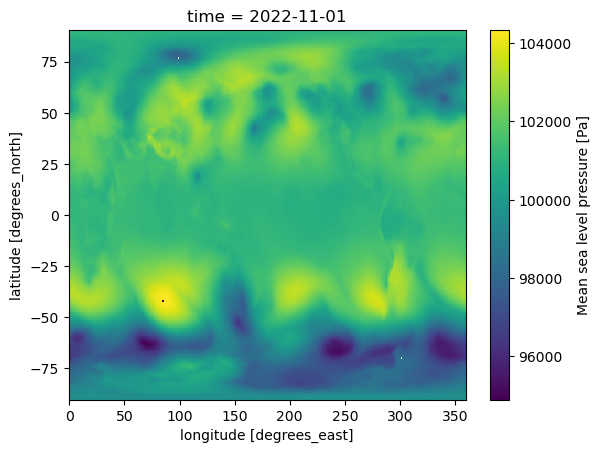

In [4]:
da.sel(time=ref_time).plot()

## Streaming ERA5 from NSF NCAR GDEX via OSDF

To access the streaming version of the data, we are following the chapter [Using PelicanFS via FSSpec to Access Data on the OSDF](https://projectpythia.org/osdf-cookbook/notebooks/pelicanfs) from the OSDF Cookbook {cite:p}`https://doi.org/10.5281/zenodo.16802784`.

This method of streaming the data over OSDF relies on a tool called PelicanFS that provides a layer of robustness for network issues. Note that `pelicanfs` must be install in the Python environment in order for the code below to work.

````{tip}
Occasionally the following cell may fail with a 500 error (coming from bad OSDF caches). One way to avoid this is to directly read from the data origin with the `"direct_reads"` flag:
```
msl = xr.open_dataset(path, engine='zarr', storage_options={"direct_reads": True})
```
````

In [5]:
path = 'osdf:///ncar/gdex/d633000/e5.oper.an.sfc.zarr/e5.oper.an.sfc.msl.zarr'
msl = xr.open_dataset(path, engine='zarr') 
msl

<xarray.Dataset> Size: 3TB
Dimensions:            (time: 749472, latitude: 721, longitude: 1440)
Coordinates:
  * time               (time) datetime64[ns] 6MB 1940-01-01 ... 2025-06-30T23...
  * latitude           (latitude) float64 6kB 90.0 89.75 89.5 ... -89.75 -90.0
  * longitude          (longitude) float64 12kB 0.0 0.25 0.5 ... 359.5 359.8
Data variables:
    MSL                (time, latitude, longitude) float32 3TB ...
    quantization_info  |S1 1B ...
    utc_date           (time) int32 3MB ...
Attributes:
    CONVERSION_DATE:      Mon 01 Sep 2025 03:17:47 PM MDT
    CONVERSION_PLATFORM:  Linux crhtc71 5.14.21-150400.24.46-default #1 SMP P...
    Conventions:          CF-1.6
    DATA_SOURCE:          ECMWF: https://cds.climate.copernicus.eu, Copernicu...
    NCO:                  netCDF Operators version 5.3.1 (Homepage = http://n...
    NETCDF_COMPRESSION:   NCO: Precision-preserving compression to netCDF4/HD...
    NETCDF_CONVERSION:    CISL RDA: Conversion from ECMWF GRIB1 data to netCDF4.
    NETCDF_VERSION:       4.9.2
    history:              Mon Sep  1 15:27:57 2025: ncks -4 -L 1 --baa=0 --pp...

In [6]:
msl.MSL.sel(time=da.time)

<xarray.DataArray 'MSL' (time: 13, latitude: 721, longitude: 1440)> Size: 54MB
[13497120 values with dtype=float32]
Coordinates:
  * time       (time) datetime64[ns] 104B 2022-11-01 ... 2022-11-01T12:00:00
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Attributes: (12/14)
    QuantizeGranularBitGroomNumberOfSignificantDigits:  7
    ecmwf_local_table:                                  128
    ecmwf_parameter:                                    151
    grid_specification:                                 0.25 degree x 0.25 de...
    long_name:                                          Mean sea level pressure
    maximum_value:                                      106987.5625
    ...                                                 ...
    rda_dataset:                                        ds633.0
    rda_dataset_doi:                                    DOI: 10.5065/BH6N-5N20
    rda_dataset_group:                                  ERA5 atmospheric surf...
    rda_dataset_url:                                    https:/rda.ucar.edu/d...
    short_name:                                         msl
    units:                                              Pa

### Recreate the reference figure

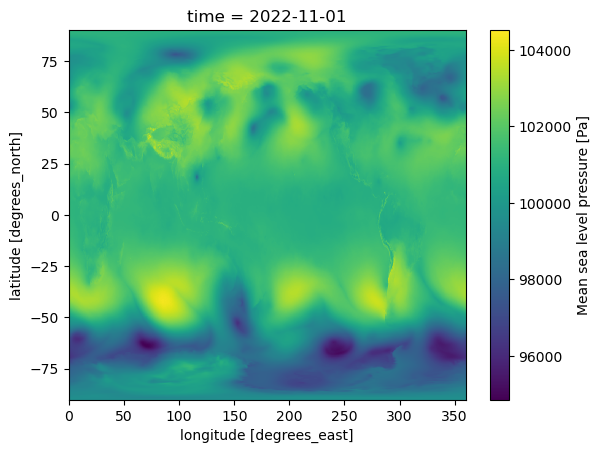

In [7]:
msl.MSL.sel(time=ref_time).plot()

## Extend a feature tracking workflow in time with streamed data

Here I'm copying code from the [SLP scikit notebook](https://projectpythia.org/feature-tracking-cookbook/notebooks/slp-scikit/) but pulling the data from GDEX and extending the time range

In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from skimage.measure import label, regionprops
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

This just pulls in a 48-hour slice of data, including the 12 hours from our example dataset.

In [ ]:
da = msl.MSL.sel(time=slice('2022-11-01','2022-11-02'))
da

Everything that follows is taken straight from the other notebook

In [ ]:
threshold = 100000
min_area = 20
min_overlap = 0.2  



# ---- get lat/lon coords ----
# assumes dims like (time, lat, lon)
lat = da[da.dims[1]].values
lon = da[da.dims[2]].values

# if lat/lon are 1D, make 2D grids for contourf/contour
lon2d, lat2d = np.meshgrid(lon, lat)

def detect_features(field, threshold=100000, min_area=20):
    mask = field <= threshold
    labels = label(mask, connectivity=2)

    for lab in np.unique(labels)[1:]:
        if np.sum(labels == lab) < min_area:
            labels[labels == lab] = 0

    labels = label(labels > 0, connectivity=2)
    return labels

# ---- precompute tracked features ----
tracked = []
prev = {}
next_track_id = 1

for t in range(da.sizes["time"]):
    field = da.isel(time=t).values
    labels = detect_features(field, threshold=threshold, min_area=min_area)

    current = {}
    frame_info = []

    for r in regionprops(labels):
        mask = labels == r.label

        best_id = None
        best_overlap = 0.0

        for track_id, old_mask in prev.items():
            overlap = np.logical_and(mask, old_mask).sum() / mask.sum()
            if overlap > best_overlap:
                best_overlap = overlap
                best_id = track_id

        if best_overlap < min_overlap:
            best_id = next_track_id
            next_track_id += 1

        current[best_id] = mask
        frame_info.append({
            "track_id": best_id,
            "centroid_rc": r.centroid,   # row, col
            "mask": mask
        })

    tracked.append(frame_info)
    prev = current


def update(t):
    ax.clear()

    field = da.isel(time=t).values

    # SLP as colored contour lines, not filled
    cs = ax.contour(
        lon2d, lat2d, field,
        levels=levels,
        cmap="turbo",          # or "rainbow", "viridis", "plasma"
        linewidths=0.9,
        transform=ccrs.PlateCarree()
    )

    # tracked feature outlines + labels
    for feat in tracked[t]:
        mask = feat["mask"]

        ax.contour(
            lon2d, lat2d, mask.astype(int),
            levels=[0.5],
            colors="black",
            linewidths=1.6,
            transform=ccrs.PlateCarree()
        )

        y, x = feat["centroid_rc"]
        iy = int(round(y))
        ix = int(round(x))

        ax.plot(
            lon[ix], lat[iy],
            "ko", ms=3,
            transform=ccrs.PlateCarree()
        )

        ax.text(
            lon[ix], lat[iy],
            str(feat["track_id"]),
            fontsize=8,
            color="black",
            ha="left",
            va="bottom",
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1)
        )

    # continents/coastlines: faint, not black
    ax.coastlines(color="0.55", linewidth=0.6)

    # faint gridlines
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="0.5",
        alpha=0.25,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False

    ax.set_title(f"Scikit tracked SLP features | time index = {t}")


In [ ]:
# ---- color scale fixed across all frames ----
vmin = float(da.min())
vmax = float(da.max())
levels = np.linspace(vmin, vmax, 16)
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
cmap = "turbo"


# ---- animate ----
fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": ccrs.PlateCarree()})

sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("SLP")


anim = FuncAnimation(
    fig,
    update,
    frames=da.sizes["time"],
    interval=300,
    blit=False,
)

plt.close(fig)
HTML(anim.to_jshtml())

Same animation, but now over 48 hours!